# 04 · Predictive models

Can 20-day recovery be forecast from what is observable at the event close?

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from deadcat import data as D, plotting as P
from deadcat.config import load_config
P.use_style(); pd.set_option("display.width", 180)
cfg = load_config(ROOT / "configs" / "default.yaml")
T = ROOT / "results" / "tables"; M = ROOT / "results" / "metrics"
print("config fingerprint:", cfg.fingerprint)

config fingerprint: a9ca33aed3d9


## Regression first

In [2]:
ols = pd.read_csv(T / "ols_primary_car20.csv")
display(ols[["label", "coef", "std_coef", "se_hc3", "ci_lo", "ci_hi",
             "p_value", "p_value_cluster"]].round(5))
print("adj R2:", round(json.load(open(M / "regressions.json"))["ols_primary"]["adj_r2"], 5))

,label,coef,std_coef,se_hc3,ci_lo,ci_hi,p_value,p_value_cluster
0,Intercept,-0.00778,NaN,0.00444,-0.01648,0.00092,0.07951,0.18531
1,Crash z-score,-0.00023,-0.00537,0.00090,-0.00200,0.00154,0.79781,0.79720
2,Abnormal volume,-0.00224,-0.01510,0.00234,-0.00682,0.00235,0.33918,0.41474
3,Momentum 20d,-0.02144,-0.01933,0.02490,-0.07024,0.02737,0.38928,0.47800
4,Realised vol 20d,0.06300,0.10059,0.01631,0.03104,0.09496,0.00011,0.00111
5,Market return (event day),0.12927,0.02994,0.11658,-0.09922,0.35776,0.26750,0.40247
6,VIX,-0.00031,-0.03732,0.00018,-0.00067,0.00005,0.08739,0.25381


adj R2: 0.00849


In [3]:
lg = pd.read_csv(T / "logit_primary_recovery.csv")
display(lg[["label", "odds_ratio_per_sd", "or_ci_lo", "or_ci_hi", "p_value"]].round(4))

,label,odds_ratio_per_sd,or_ci_lo,or_ci_hi,p_value
0,Intercept,0.8913,0.8436,0.9418,0.0000
1,Crash z-score,1.0284,0.9826,1.0763,0.2283
2,Abnormal volume,1.0030,0.9425,1.0672,0.9259
3,Momentum 20d,0.9891,0.9380,1.0429,0.6840
4,Realised vol 20d,1.0820,1.0142,1.1543,0.0170
5,Market return (event day),0.9831,0.8985,1.0756,0.7103
6,VIX,0.9281,0.8361,1.0301,0.1609


## Multiplicity

In [4]:
fam = pd.read_csv(T / "fdr_exploratory_coefficients.csv")
print(f"{len(fam)} exploratory coefficients, {int(fam.reject_fdr.sum())} survive q<=0.05")
display(fam.sort_values("p_value").head(8).round(5))

32 exploratory coefficients, 0 survive q<=0.05


,model,term,p_value,q_value,reject_fdr
29,logit_extended,vix,0.02508,0.76401,False
26,logit_extended,rv_ratio,0.04779,0.76401,False
13,ols_extended,vix,0.08070,0.76401,False
28,logit_extended,spy_mom_20,0.10664,0.76401,False
25,logit_extended,rv_60,0.11938,0.76401,False
23,logit_extended,mom_252,0.15653,0.83484,False
7,ols_extended,mom_252,0.21296,0.91200,False
3,ols_extended,avol,0.24715,0.91200,False


## The predictive experiment

Chronological, embargoed, scored once.

In [5]:
mo = json.load(open(M / "models.json"))
print(json.dumps(mo["split"], indent=2))
comp = pd.read_csv(T / "model_comparison.csv")
display(comp[["model", "roc_auc", "pr_auc", "brier", "log_loss",
              "brier_skill_vs_base_rate", "accuracy"]].round(4))

{
  "train_end": "2021-10-21",
  "val_end": "2024-06-24",
  "embargo_calendar_days": 29,
  "n_train": 10189,
  "n_val": 2160,
  "n_test": 2199,
  "n_embargoed": 99
}


,model,roc_auc,pr_auc,brier,log_loss,brier_skill_vs_base_rate,accuracy
0,logistic,0.5041,0.4775,0.2496,0.6924,-0.0024,0.5239
1,random_forest,0.4990,0.4769,0.2499,0.6930,-0.0035,0.5157
2,lightgbm,0.4765,0.4363,0.2564,0.7064,-0.0297,0.4934
3,base_rate,0.5000,0.4688,0.2490,0.6912,-0.0001,0.5312


Every Brier skill score is **negative**: each model is slightly *worse* than predicting the base rate for every event. Note also that the base-rate model has the highest accuracy while making one constant prediction — which is why accuracy is reported last.

In [6]:
exp = pd.read_csv(T / "expanding_window.csv")
display(exp.pivot_table(index="fold", columns="model", values="roc_auc").round(4))
print("\nmean across folds:")
display(exp.groupby("model")[["roc_auc", "brier", "log_loss"]].mean().round(4))

model,lightgbm,logistic,random_forest
fold,,,
0,0.5243,0.5068,0.5116
1,0.5482,0.5277,0.5307
2,0.5056,0.4972,0.5235
3,0.4919,0.5034,0.5129
4,0.4569,0.4936,0.4884



mean across folds:


,roc_auc,brier,log_loss
model,,,
lightgbm,0.5054,0.2528,0.6991
logistic,0.5057,0.2492,0.6916
random_forest,0.5134,0.2491,0.6914


## Calibration — the one thing that works

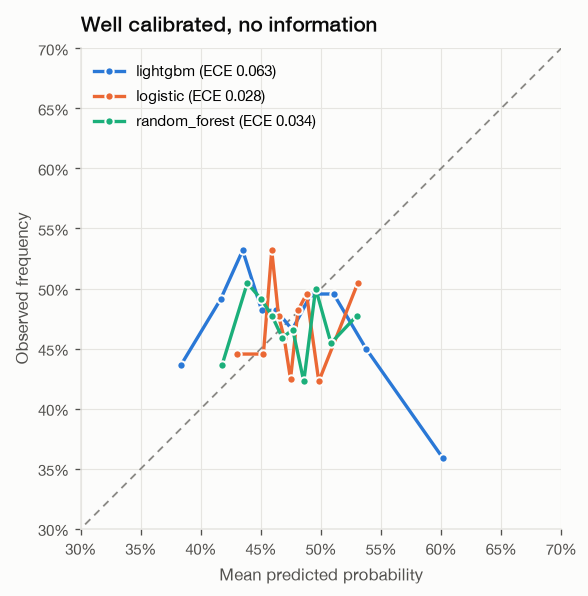

In [7]:
cal = pd.read_csv(T / "calibration.csv")
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot([0, 1], [0, 1], color=P.INK_MUTED, ls=(0, (4, 3)), lw=1.1)
for i, (name, g) in enumerate(cal.groupby("model")):
    ax.plot(g.mean_pred, g.observed_freq, marker="o", ms=5, lw=2,
            color=P.CATEGORICAL[i], label=f"{name} (ECE {g.ece.iloc[0]:.3f})",
            markeredgecolor=P.SURFACE, markeredgewidth=1.2)
ax.set_xlim(0.3, 0.7); ax.set_ylim(0.3, 0.7); ax.set_aspect("equal")
P.pct_axis(ax, "x", 0); P.pct_axis(ax, "y", 0); ax.legend(loc="upper left")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
P.finish(fig, ax, "Well calibrated, no information")
plt.show()

## Do the interpretations agree?

In [8]:
shap_r = pd.read_csv(T / "shap_importance.csv").head(8)
perm = pd.read_csv(T / "permutation_importance.csv").head(8)
coef = pd.read_csv(T / "logistic_model_coefficients.csv").head(8)
print("SHAP:", shap_r.feature.tolist())
print("Perm:", perm.feature.tolist())
print("Logit:", coef.feature.tolist())
print("\nThree methods, three different rankings - the signature of ranking noise.")

SHAP: ['vix_chg', 'spy_mom_20', 'vix', 'sector_ret_event', 'rv_ratio', 'mom_60', 'mom_252', 'crash_z']
Perm: ['avol', 'sector_ret_event', 'excess_vs_sector', 'volume', 'rv_60', 'log_volume', 'mom_20', 'crash_z']
Logit: ['rv_60', 'mom_5', 'spy_mom_20', 'volume', 'vix_chg', 'crash_z', 'rv_ratio', 'vix']

Three methods, three different rankings - the signature of ranking noise.
